In [1]:
# Config & imports

import os
import numpy as np
import pandas as pd

# Modeling
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_predict, cross_val_score

# Metrics & plots
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    precision_recall_fscore_support
)
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# I/O
DATA_PATH = "./data/train_mp.csv"  # adjust if needed
os.makedirs("./visual", exist_ok=True)

# Columns to exclude from features (same as your regression script)
NON_FEATURE_COLS = {
    "material_id", "formula", "composition", "composition_obj",
    "formation_energy_per_atom", "band_gap"
}

# Class labels for plots
CLASS_NAMES = ["C", "SC"]  # 0, 1


In [2]:
# Load data & build class y

df = pd.read_csv(DATA_PATH)

# Features: all except excluded, keep only numeric
feature_cols = [c for c in df.columns if c not in NON_FEATURE_COLS]
X_all = df[feature_cols].select_dtypes(include=[np.number]).copy()

# Build binary labels from band_gap
bg = pd.to_numeric(df["band_gap"], errors="coerce")

# Define classes
# - conductor (0): band_gap == 0.0  (tolerance handles tiny floating noise)
# - semiconductor (1): 0.1 ≤ band_gap ≤ 3.0
tol = 1e-8
y_all = pd.Series(np.nan, index=bg.index, dtype="float64")

y_all[(bg >= 0.1) & (bg <= 3.0)] = 1
y_all[np.abs(bg - 0.0) <= tol] = 0

# Keep only rows that match the spec (drop others)
mask_valid = y_all.notna()
dropped = (~mask_valid).sum()
print(f"Total rows: {len(df)} | Kept (classified): {mask_valid.sum()} | Dropped (outside spec): {dropped}")

X_all = X_all.loc[mask_valid].reset_index(drop=True)
y_all = y_all.loc[mask_valid].astype(int).reset_index(drop=True)

print("Class counts:", dict(zip(*np.unique(y_all, return_counts=True))))
print("n_features (numeric):", X_all.shape[1])
print("first 5 feature columns:", feature_cols[:5])
X_all.head()


Total rows: 6419 | Kept (classified): 5584 | Dropped (outside spec): 835
Class counts: {np.int64(0): np.int64(3340), np.int64(1): np.int64(2244)}
n_features (numeric): 250
first 5 feature columns: ['H', 'He', 'Li', 'Be', 'B']


,H,He,Li,Be,B,C,N,O,F,Ne,...,MagpieData range GSmagmom,MagpieData mean GSmagmom,MagpieData avg_dev GSmagmom,MagpieData mode GSmagmom,MagpieData minimum SpaceGroupNumber,MagpieData maximum SpaceGroupNumber,MagpieData range SpaceGroupNumber,MagpieData mean SpaceGroupNumber,MagpieData avg_dev SpaceGroupNumber,MagpieData mode SpaceGroupNumber
0,0.0,0,0.0,0,0.0,0.750000,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,229.0,35.0,202.750000,13.125000,194.0
1,0.0,0,0.0,0,0.0,0.200000,0.0,0.0,0.0,0,...,2.110663,1.68853,0.675412,2.110663,194.0,229.0,35.0,222.000000,11.200000,229.0
2,0.0,0,0.0,0,0.0,0.558824,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,194.0,0.0,194.000000,0.000000,194.0
3,0.0,0,0.0,0,0.0,0.600000,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,194.0,0.0,194.000000,0.000000,194.0
4,0.0,0,0.0,0,0.0,0.555556,0.0,0.0,0.0,0,...,0.000000,0.00000,0.000000,0.000000,194.0,225.0,31.0,207.777778,15.308642,194.0


In [3]:
# Train/test split & basic imputation

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=RANDOM_STATE, stratify=y_all
)

# Simple median imputation
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))  # use train medians

print("train shape:", X_train.shape, "| test shape:", X_test.shape)
print("train class counts:", dict(zip(*np.unique(y_train, return_counts=True))))
print("test  class counts:", dict(zip(*np.unique(y_test, return_counts=True))))


train shape: (4467, 250) | test shape: (1117, 250)
train class counts: {np.int64(0): np.int64(2672), np.int64(1): np.int64(1795)}
test  class counts: {np.int64(0): np.int64(668), np.int64(1): np.int64(449)}


In [4]:
# Model & hyperparameter search (F1-macro)

clf = RandomForestClassifier(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    class_weight="balanced"  # helpful if classes are imbalanced
)

param_grid = {
    "n_estimators": [300, 600],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", "log2", 0.5],
    "bootstrap": [True]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

gscv = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring="f1_macro",      # robust for imbalance
    cv=cv,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

gscv.fit(X_train, y_train)
best_clf = gscv.best_estimator_
print("best params:", gscv.best_params_)
print("best cv F1_macro:", gscv.best_score_)


Fitting 5 folds for each of 72 candidates, totalling 360 fits
best params: {'bootstrap': True, 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 600}
best cv F1_macro: 0.8598725443293922


In [5]:
# Metrics helper + train/test evaluation

def summarize_classification(y_true, y_pred, label=""):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, support = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    print(f"{label} Acc: {acc:.3f} | P: {p:.3f} | R: {r:.3f} | F1: {f1:.3f}")
    print("\nClassification report:\n", 
          classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))
    return acc, p, r, f1

# Predictions
yhat_tr = best_clf.predict(X_train)
yhat_te = best_clf.predict(X_test)

print("== training ==")
tr_metrics = summarize_classification(y_train, yhat_tr, "Train")

print("\n== test ==")
te_metrics = summarize_classification(y_test, yhat_te, "Test")


== training ==
Train Acc: 0.960 | P: 0.957 | R: 0.961 | F1: 0.959

Classification report:
               precision    recall  f1-score   support

           C       0.98      0.96      0.97      2672
          SC       0.94      0.97      0.95      1795

    accuracy                           0.96      4467
   macro avg       0.96      0.96      0.96      4467
weighted avg       0.96      0.96      0.96      4467


== test ==
Test Acc: 0.865 | P: 0.859 | R: 0.862 | F1: 0.860

Classification report:
               precision    recall  f1-score   support

           C       0.89      0.88      0.89       668
          SC       0.82      0.85      0.83       449

    accuracy                           0.86      1117
   macro avg       0.86      0.86      0.86      1117
weighted avg       0.87      0.86      0.87      1117



In [6]:
# Cross-validation predictions & scores

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Macro F1, Accuracy in CV
cv_f1  = cross_val_score(best_clf, X_all, y_all, cv=cv, scoring="f1_macro", n_jobs=-1)
cv_acc = cross_val_score(best_clf, X_all, y_all, cv=cv, scoring="accuracy",  n_jobs=-1)

print(f"CV F1_macro: mean={cv_f1.mean():.3f} ± {cv_f1.std():.3f}")
print(f"CV Accuracy: mean={cv_acc.mean():.3f} ± {cv_acc.std():.3f}")

# Out-of-fold predictions for confusion matrix
yhat_cv = cross_val_predict(best_clf, X_all, y_all, cv=cv, n_jobs=-1, method="predict")


CV F1_macro: mean=0.859 ± 0.012
CV Accuracy: mean=0.864 ± 0.011


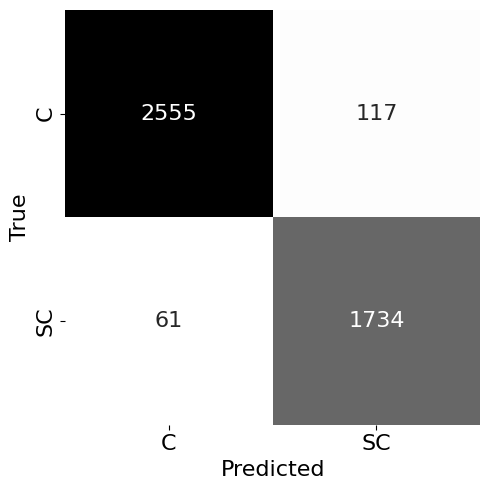

In [7]:
# Confusion Matrix (train)

cm_train = confusion_matrix(y_train, yhat_tr, labels=[0,1])

plt.figure(figsize=(5,5))
sns.heatmap(
    cm_train, annot=True, fmt="d", cmap="Greys",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cbar=False, annot_kws={"size": 16}
)

plt.xlabel("Predicted", fontsize=16)
plt.ylabel("True", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig("./visual/fig_s2a.jpg", format="jpg", dpi=500, bbox_inches="tight")
plt.show()


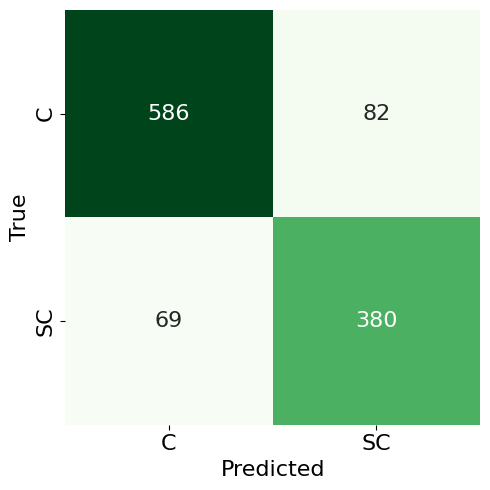

In [8]:
# Confusion Matrix (test)

cm_test = confusion_matrix(y_test, yhat_te, labels=[0,1])

plt.figure(figsize=(5,5))
sns.heatmap(
    cm_test, annot=True, fmt="d", cmap="Greens",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cbar=False, annot_kws={"size": 16}
)
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("True", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig("./visual/fig3a.jpg", format="jpg", dpi=500, bbox_inches="tight")
plt.show()


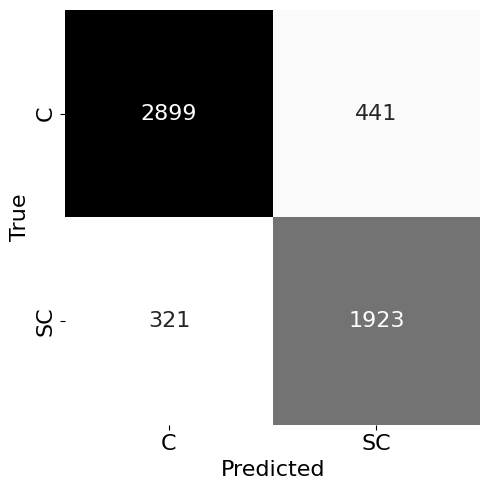

In [13]:
# Confusion Matrix (CV / OOF)

cm_cv = confusion_matrix(y_all, yhat_cv, labels=[0,1])

plt.figure(figsize=(5,5))
sns.heatmap(
    cm_cv, annot=True, fmt="d", cmap="Greys",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cbar=False, annot_kws={"size": 16}
)
plt.xlabel("Predicted", fontsize=16)
plt.ylabel("True", fontsize=16)
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig("./visual/fig_s2b.jpg", format="jpg", dpi=500, bbox_inches="tight")
plt.show()


In [ ]:
# # Feature importance (top-10) + lookup

# importances = pd.Series(best_clf.feature_importances_, index=X_train.columns)

# imp_top = importances.sort_values(ascending=False).head(10)

# # Map original feature names → Feature #XXX
# feature_map = {
#     feat: f"#{str(X_train.columns.get_loc(feat)+1).zfill(3)}"
#     for feat in imp_top.index
# }
# imp_top_short = imp_top.rename(index=feature_map)

# plt.figure(figsize=(5.5,5))
# sns.barplot(
#     x=imp_top_short.values,
#     y=imp_top_short.index,
#     palette="viridis"
# )
# plt.xlabel("Importance", fontsize=16)
# plt.ylabel("Feature", fontsize=16)

# # Ticks like 0.00, 0.05, 0.10 ...
# max_val = max(imp_top_short.max(), 0.15)
# ticks = np.arange(0, max_val + 0.05, 0.05)
# plt.xticks(ticks, fontsize=16)
# plt.yticks(fontsize=16)

# plt.tight_layout()
# plt.savefig("./visual/fig3d.jpg", format="jpg", dpi=500, bbox_inches="tight")
# plt.show()

# # Lookup table for reference
# lookup = pd.DataFrame.from_dict(feature_map, orient="index", columns=["Short name"])
# lookup


In [ ]:
# =======================================================
# (Optional) Predict on a new feature-only file
# =======================================================
# Uncomment & set path to use:
# new_features_path = "/mnt/data/new_features.csv"  # feature-only table
# out_path = "/mnt/data/pred_bandgap_class.csv"

# new_df = pd.read_csv(new_features_path)

# # Ensure same columns & order as training
# missing = set(X_train.columns) - set(new_df.columns)
# if missing:
#     raise ValueError(f"Missing required feature columns: {sorted(list(missing))[:10]} ...")
# X_new = new_df.reindex(columns=X_train.columns, fill_value=np.nan)
# X_new = X_new.fillna(X_train.median(numeric_only=True))

# pred_cls = best_clf.predict(X_new)
# pred_name = pd.Series(pred_cls).map({0:"conductor", 1:"semiconductor"})

# out = new_df.copy()
# out["predicted_class"] = pred_cls
# out["predicted_label"] = pred_name
# out.to_csv(out_path, index=False)
# print(f"Saved predictions to: {out_path}")
# out.head()
